# 2D Bayesian RL Environment Quickstart
This notebook provides a minimal starting point for experiments with the 100x100 grid environment.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import sys
import numpy as np
from matplotlib.patches import Circle, Patch

start_state = (0, 0)

def plot_agent(location, ax=None, radius=1.2):
    x, y = location
    agent = Circle((x, y), radius=radius, color='red', zorder=3)
    ax.add_patch(agent)

    # Draw white 'A' in the center
    ax.text(
        x, y, 'A',
        color='white',
        fontsize=12,
        fontweight='bold',
        ha='center',    
        va='center',
        zorder=4
    )

# Ensure project root (parent of notebooks/) is on PYTHONPATH
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.environment_2 import ProbabilisticSimpleSystem

env = ProbabilisticSimpleSystem(seed=67, num_unsafe_blocks=5)
env2 = ProbabilisticSimpleSystem(seed=89, num_unsafe_blocks=5)
env.add_hill(top=(30, 70), sigma=15.0, strength=35, normalized=False)
env.add_hill(top=(60, 20), sigma = 10, strength=15.0, normalized=False)
env.add_hill(top=(75, 55), sigma = -10, strength=-20.0, normalized=False)
env2.add_hill(top=(15, 85), sigma=5.0, strength=5, normalized=False)
env2.add_hill(top=(50, 50), sigma=20.0, strength=-20, normalized=False)
env2.add_hill(top=(80, 20), sigma=10.0, strength=20, normalized=False)
env2.add_hill(top=(55, 40), sigma=7.0, strength=10, normalized=False)
env2.add_hill(top=(40, 10) ,sigma=15.0, strength=-17, normalized=False)

/Users/thijsvanschaik/Desktop/school/Uni/year4_last_hopefully/thesis_yehes/starting_fr_fr/BayesianRLunderUncertainty/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


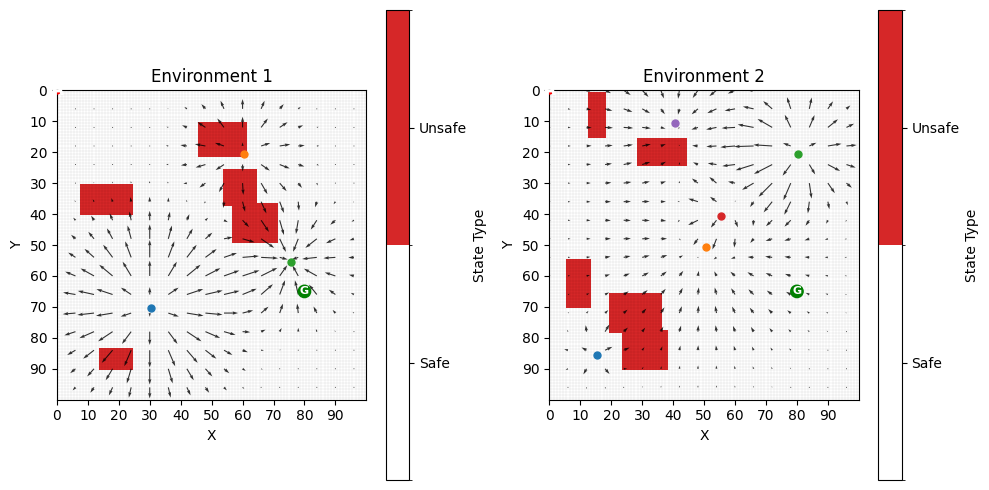

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
env.plot_unsafe_mask(ax=ax[0])
env.plot_hills(ax=ax[0])
plot_agent(start_state, ax=ax[0])
x_top, y_top = env.reward_gaussian_mean

goal = Circle((x_top, y_top), radius=2, color='green', zorder=3)
ax[0].add_patch(goal)

# Draw white 'G' in the center
ax[0].text(
    x_top, y_top, 'G',
    color='white',
    fontsize=8,
    fontweight='bold',
    ha='center',
    va='center',
    zorder=4
) 
ax[0].set_title('Environment 1')

env2.plot_unsafe_mask(ax=ax[1])
env2.plot_hills(ax=ax[1])
plot_agent(start_state, ax=ax[1])
x_top, y_top = env2.reward_gaussian_mean

goal = Circle((x_top, y_top), radius=2, color='green', zorder=3)
ax[1].add_patch(goal)

# Draw white 'G' in the center
ax[1].text(
    x_top, y_top, 'G',
    color='white',
    fontsize=8,
    fontweight='bold',
    ha='center',
    va='center',
    zorder=4
) 
ax[1].set_title('Environment 2')

plt.tight_layout()

## Transition Function Visualization
Sample the transition function many times and visualize where we end up.

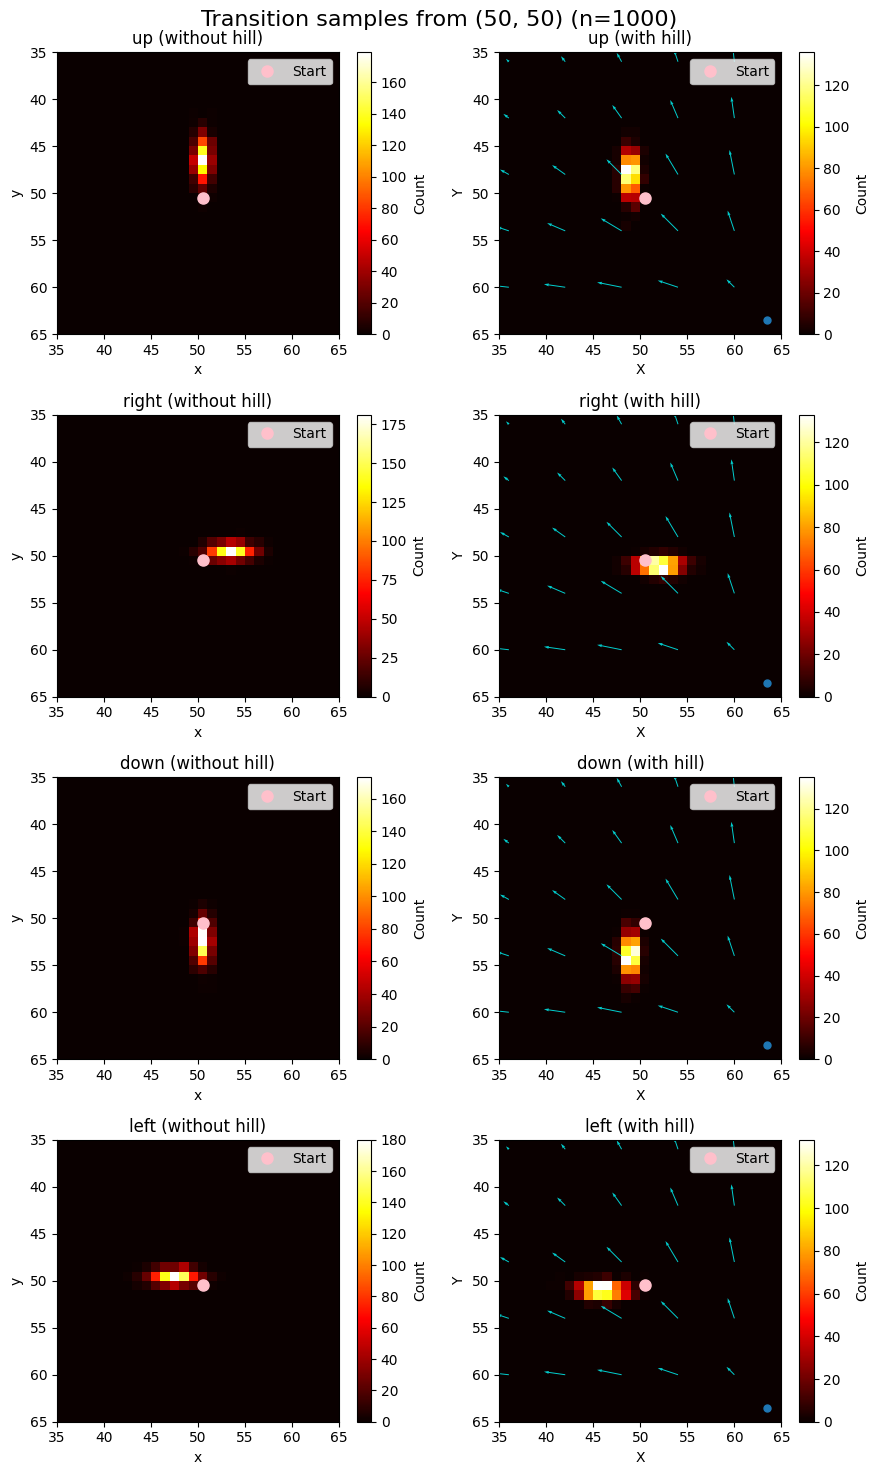

In [3]:
env3 = ProbabilisticSimpleSystem(seed=123, num_unsafe_blocks=5)
env4 = ProbabilisticSimpleSystem(seed=456, num_unsafe_blocks=5)
env4.add_hill(top=(63, 63), sigma=15.0, strength=55, normalized=False)
start_state = (50, 50)
n_samples = 1000

# Actions: [up, right, down, left]
actions = {
    'up': (0, 1),
    'right': (1, 0),
    'down': (0, -1),
    'left': (-1, 0),
}

def sample_counts(env, start_state, action, n_samples, grid_size=100):
    counts = np.zeros((grid_size, grid_size))
    for _ in range(n_samples):
        x, y = env.transition(start_state, action)
        counts[y, x] += 1
    return counts

# Zoom region around start state
zoom = 15
x0, y0 = start_state
x_min, x_max = max(0, x0 - zoom), min(100, x0 + zoom)
y_min, y_max = max(0, y0 - zoom), min(100, y0 + zoom)

fig, axs = plt.subplots(4, 2, figsize=(9, 15))

for row, (action_name, action) in enumerate(actions.items()):

    # Two independent samples
    counts1 = sample_counts(env3, start_state, action, n_samples)
    counts2 = sample_counts(env4, start_state, action, n_samples)

    zoomed1 = counts1[y_min:y_max, x_min:x_max]
    zoomed2 = counts2[y_min:y_max, x_min:x_max]

    ax0, ax1 = axs[row]

    # Left plot
    im0 = ax0.imshow(
        zoomed1,
        cmap="hot",
        extent=[x_min, x_max, y_min, y_max]
    )
    ax0.plot(x0 + 0.5, y0 + 0.5, "o", color="pink",
             markersize=8, label="Start")
    ax0.set_title(f"{action_name} (without hill)")
    ax0.set_xlabel("x")
    ax0.set_ylabel("y")
    ax0.legend()
    ax0.invert_yaxis()

    # Right plot
    im1 = ax1.imshow(
        zoomed2,
        cmap="hot",
        extent=[x_min, x_max, y_min, y_max]
    )
    ax1.plot(x0 + 0.5, y0 + 0.5, "o", color="pink",

             markersize=8, label="Start")
    ax1.set_title(f"{action_name} (with hill)")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.legend()

    env4.plot_hills(color="cyan", ax=ax1)

    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    ax1.invert_yaxis()

    plt.colorbar(im0, ax=ax0, label="Count")
    plt.colorbar(im1, ax=ax1, label="Count")

plt.suptitle(
    f"Transition samples from {start_state} (n={n_samples})",
    fontsize=16
)
plt.tight_layout()
plt.show()

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.GP import BoTorchDualSingleTaskGP

actions = {
    'up': (0, -1),
    'right': (1, 0),
    'down': (0, 1),
    'left': (-1, 0),
}

def plot_ll_heatmap_simple(model, 
                           start_positions, 
                           env, 
                           actions, 
                           grid_resolution=100, 
                           n_samples_per_cell=50, 
                           cmap='RdYlGn',
                           ax=None,
                           show_hills=True,
                           show_start_positions=True,
                           colorbar_label='Log Likelihood'
                           ):

    x_coords = np.linspace(0, 99, grid_resolution)
    y_coords = np.linspace(0, 99, grid_resolution)

    log_likelihood_map = np.zeros((grid_resolution, grid_resolution))

    model.eval()

    for i, x in enumerate(x_coords):
        for j, y in enumerate(y_coords):
            state = (int(x), int(y))
            total_log_prob = 0
            
            for action_name, action in actions.items():
                x_input = torch.tensor([[state[0], state[1], action[0], action[1]]], dtype=torch.float64)
                pred_mean, pred_cov = model.predict(x_input)
                pred_mean = pred_mean.squeeze()
                
                for _ in range(n_samples_per_cell):
                    next_state = env.transition(state, action)
                    next_state_tensor = torch.tensor([next_state[0], next_state[1]], dtype=torch.float64)
                    
                    try:
                        dist = torch.distributions.MultivariateNormal(pred_mean, pred_cov)
                        log_prob = dist.log_prob(next_state_tensor).item()
                    except:
                        log_prob = -10
                    
                    total_log_prob += log_prob
            
            log_likelihood_map[j, i] = total_log_prob / (len(actions) * n_samples_per_cell)
        
        if (i + 1) % 10 == 0:
            print(f"Processed row {i+1}/{grid_resolution}")

    # Use provided bounds or auto-detect
    plot_vmin = log_likelihood_map.min()
    plot_vmax = log_likelihood_map.max()

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Single colormap for entire range
    im = ax.imshow(log_likelihood_map, cmap=cmap, origin='lower', 
                   extent=[0, 100, 0, 100], aspect='equal', 
                   vmin=plot_vmin, vmax=plot_vmax)

    plt.colorbar(im, ax=ax, label=colorbar_label)

    if show_start_positions:
        for pos in start_positions:
            ax.plot(pos[0], pos[1], 'w*', markersize=15, markeredgecolor='black', markeredgewidth=1)

    if show_hills:
        env.plot_hills(ax=ax)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('GP Model Log Likelihood Heatmap')

    print(f"\nLog likelihood statistics:")
    print(f"  Min: {log_likelihood_map.min():.2f}")
    print(f"  Max: {log_likelihood_map.max():.2f}")
    print(f"  Mean: {log_likelihood_map.mean():.2f}")
    
    return ax, log_likelihood_map


def plot_visited_overlay(states_visited, ax=None, color='blue', min_alpha=0.1, max_alpha=0.9, show_colorbar=True):
    from matplotlib.colors import to_rgba
    
    grid_size = 100
    visit_counts = np.zeros((grid_size, grid_size))
    
    for state, count in states_visited.items():
        x, y = state
        if 0 <= x < grid_size and 0 <= y < grid_size:
            visit_counts[y, x] = count
    
    # Get max visits for normalization
    max_visits = visit_counts.max()
    if max_visits == 0:
        return ax
    
    base_color = to_rgba(color)[:3]
    
    # Normalize
    normalized_counts = visit_counts / max_visits
    
    # Scale alpha
    alpha_map = np.where(visit_counts > 0, 
                         min_alpha + normalized_counts * (max_alpha - min_alpha),
                         0)
    
    rgba_image = np.zeros((grid_size, grid_size, 4))
    rgba_image[:, :, 0] = base_color[0]  # R
    rgba_image[:, :, 1] = base_color[1]  # G
    rgba_image[:, :, 2] = base_color[2]  # B
    rgba_image[:, :, 3] = alpha_map      # A (scaled by visit count)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.imshow(rgba_image, origin='lower', extent=[0, 100, 0, 100], aspect='equal')
    
    if show_colorbar:
        # Create a fake ScalarMappable for the colorbar to show visit counts
        import matplotlib.cm as cm
        from matplotlib.colors import Normalize as mplNormalize
        
        # Create a colormap that goes from transparent to solid color
        from matplotlib.colors import LinearSegmentedColormap
        cmap_alpha = LinearSegmentedColormap.from_list(
            'alpha_scale', 
            [(base_color[0], base_color[1], base_color[2], min_alpha),
             (base_color[0], base_color[1], base_color[2], max_alpha)]
        )
        sm = cm.ScalarMappable(cmap=cmap_alpha, norm=mplNormalize(vmin=1, vmax=max_visits))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='Visit Count', shrink=0.6)
    
    return ax

Processed row 10/50
Processed row 20/50
Processed row 30/50
Processed row 40/50
Processed row 50/50

Log likelihood statistics:
  Min: -16.90
  Max: -3.20
  Mean: -5.57
Processed row 10/50
Processed row 20/50
Processed row 30/50
Processed row 40/50
Processed row 50/50

Log likelihood statistics:
  Min: -41.03
  Max: -3.12
  Mean: -10.32
Processed row 10/50
Processed row 20/50
Processed row 30/50
Processed row 40/50
Processed row 50/50

Log likelihood statistics:
  Min: -29.57
  Max: -2.99
  Mean: -6.04


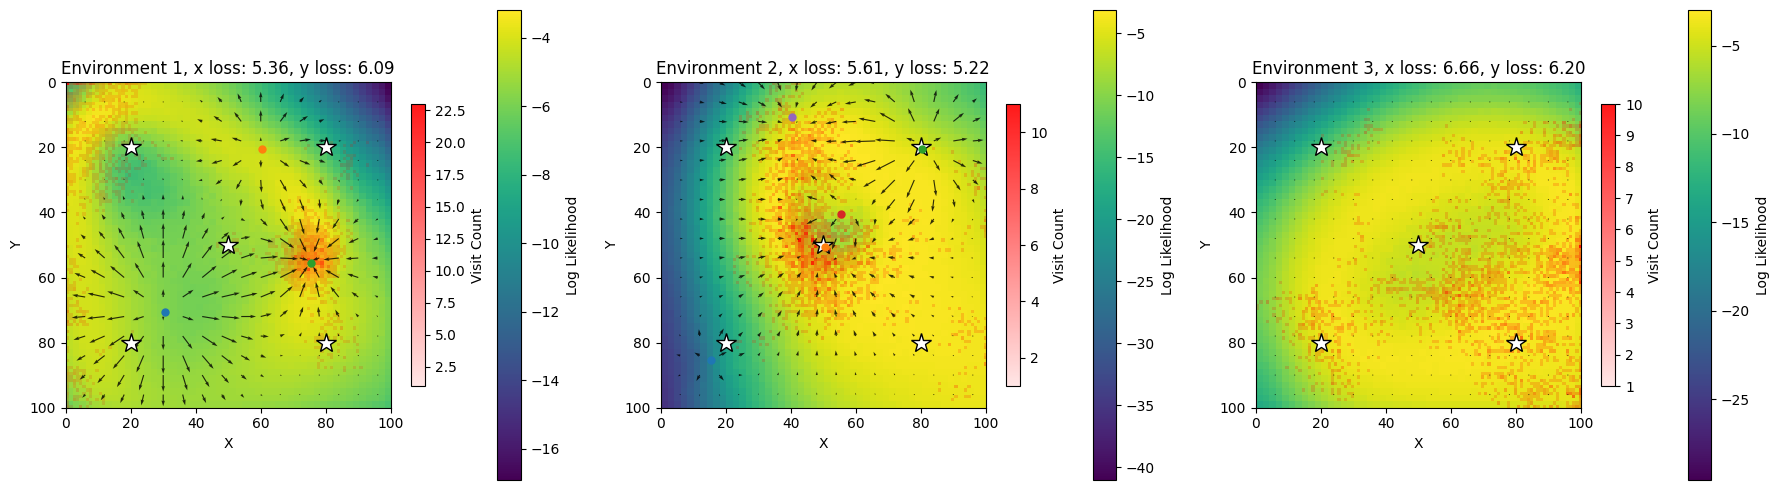

In [5]:
envs = [env, env2, env3]
starting_pos = [(50, 50), (20, 20), (80, 80), (20, 80), (80, 20)]
unsafe_counts = [[] for _ in range(len(envs))]
models = []


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, env in enumerate(envs):
    train_x, train_y, states_visited, gp_unsafe_count = BoTorchDualSingleTaskGP.get_random_train_data(env=env, 
                                                                                                        start_positions=starting_pos,
                                                                                                        walks=1, 
                                                                                                        walk_length=500)
    model = BoTorchDualSingleTaskGP(train_x, train_y)
    losses_x, losses_y = model.fit(training_iterations=100, lr=0.1, verbose=False)

    models.append(model)
    unsafe_counts[i].append(gp_unsafe_count)

    plot_ll_heatmap_simple(
        model, starting_pos, env, actions,
        grid_resolution=50, 
        n_samples_per_cell=100,
        cmap='viridis',
        ax=axes[i],
        show_hills=True,
        show_start_positions=True,
        colorbar_label='Log Likelihood'
    )
    plot_visited_overlay(states_visited, ax=axes[i], color='red', min_alpha=0.1, max_alpha=0.9, show_colorbar=True)
    axes[i].set_title(f'Environment {i+1}, x loss: {losses_x[-1]:.2f}, y loss: {losses_y[-1]:.2f}')

plt.tight_layout()
plt.show()

In [6]:
from scipy.stats import norm

def action_estimate_without_policy(model, action = (0, -1), env=env):
    max_x, max_y = env.grid_shape

    pred_mean_without_policy = np.zeros((max_x, max_y, 2), dtype=np.float64)      # [x, y, mean_x, mean_y]
    pred_cov_without_policy  = np.zeros((max_x, max_y, 2, 2), dtype=np.float64)   # [x, y, cov(2x2)]

    for x in range(max_x):
        for y in range(max_y):
            x_input = torch.tensor([[x, y, action[0], action[1]]], dtype=torch.float64)
            pred_mean, pred_cov = model.predict(x_input)

            mean_np = pred_mean.squeeze(0).detach().cpu().numpy()   # shape (2,)
            cov_np  = pred_cov.detach().cpu().numpy()               # shape (2,2)

            pred_mean_without_policy[x, y] = mean_np
            pred_cov_without_policy[x, y] = cov_np

    return pred_mean_without_policy, pred_cov_without_policy



def calc_quantative_reachability_values(S, S_q, q, pred_mean, pred_cov, env=env):
    # from The Probabilistic Model Checking Landscape by Joost-Pieter Katoen
    # Vectorized for np.arrays as otherwise computation took over 30 mins
    max_x, max_y = env.grid_shape

    N = len(S)
    M = len(S)

    pred_mean = np.array(pred_mean)  
    pred_cov = np.array(pred_cov)   

    means = pred_mean[S[:,0], S[:,1]]   # (N,2)
    covs  = pred_cov[S[:,0], S[:,1]]    # (N,2,2)

    mean_x = means[:, 0][:, None]   # (N,1)
    mean_y = means[:, 1][:, None]

    std_x = np.sqrt(covs[:, 0, 0])[:, None]
    std_y = np.sqrt(covs[:, 1, 1])[:, None]

    nx = S[:, 0][None, :]   # (1,M)
    ny = S[:, 1][None, :]

    x_lo = np.where(nx == 0, -np.inf,
                    np.where(nx == max_x-1, nx - 0.5, nx - 0.5))

    x_hi = np.where(nx == 0, 0.5,
                    np.where(nx == max_x-1, np.inf, nx + 0.5))

    y_lo = np.where(ny == 0, -np.inf,
                    np.where(ny == max_y-1, ny - 0.5, ny - 0.5))

    y_hi = np.where(ny == 0, 0.5,
                    np.where(ny == max_y-1, np.inf, ny + 0.5))

    p_x = norm.cdf(x_hi, loc=mean_x, scale=std_x) - norm.cdf(x_lo, loc=mean_x, scale=std_x)

    p_y = norm.cdf(y_hi, loc=mean_y, scale=std_y) - norm.cdf(y_lo, loc=mean_y, scale=std_y)

    full_P_est_pi = p_x * p_y

    # resize 10000x10000 to 100x100x100x100 for easier indexing
    P_a_overline = full_P_est_pi.reshape(
        max_x, max_y, max_x, max_y
    )

    x = S_q[:, 0]
    y = S_q[:, 1]

    A = P_a_overline[x[:, None], y[:, None], x[None, :], y[None, :]]

    qx = q[:, 0]
    qy = q[:, 1]

    b_ = P_a_overline[x[:, None], y[:, None], qx[None, :], qy[None, :]].sum(axis=1)
    return A, b_

In [7]:
class QuantitativeReachabilityResult:
    def __init__(self, A, b_):
        self.A = A
        self.b_ = b_

    def get_k_step_reachability(self, k, gamma = 1.0):
        result = self.b_.copy()
        if k == 1:
            return self.b_
        for i in range(k-1):
            result += (gamma * self.A)**(i+1) @ self.b_
        return result
    
class StateSets:
    def __init__(self, S, S_q, q):
        self.S = S
        self.S_q = S_q
        self.q = q

In [8]:
qrvs = [[], [], []]
state_sets = []


for i, env in enumerate(envs):
    model = models[i]
    S_q = np.flip(np.argwhere(~env.unsafe_mask), axis=1)
    q = np.flip(np.argwhere(env.unsafe_mask), axis=1)
    S = np.array([(s_x, s_y) for s_x in range(100) for s_y in range(100)])
    state_sets.append(StateSets(S, S_q, q))
    for action in actions.values():
        pred_mean, pred_cov = action_estimate_without_policy(model, action=action, env=env)
        A, b_ = calc_quantative_reachability_values(S, S_q, q, pred_mean, pred_cov, env=env)
        qrvs[i].append(QuantitativeReachabilityResult(A, b_))

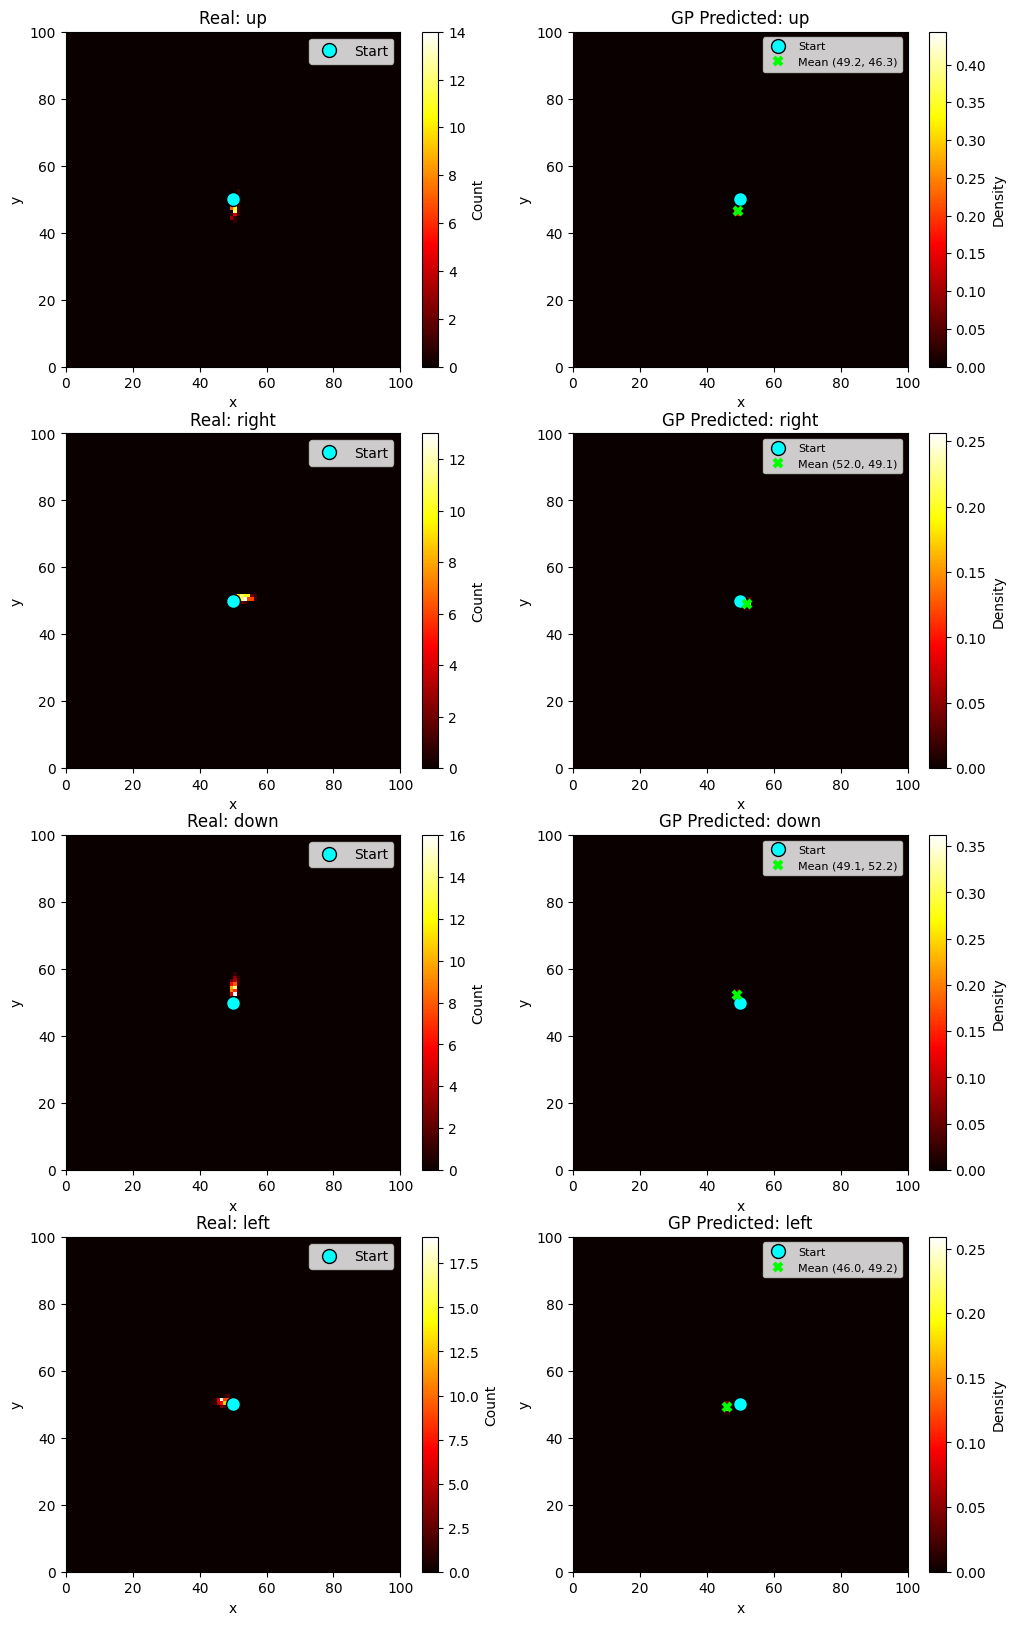

In [9]:
from scipy.stats import multivariate_normal

start_state = (50, 50)
n_samples = 100
model = models[1]  # Use the model for env2

fig, axs = plt.subplots(4, 2, figsize=(12, 20))

for row, (action_name, action) in enumerate(actions.items()):
    ax_real = axs[row, 0]
    ax_gp = axs[row, 1]
    
    # Build input for GP
    x_input = torch.tensor([[start_state[0], start_state[1], action[0], action[1]]], dtype=torch.float64)
    
    pred_mean, pred_cov = model.predict(x_input)
    pred_mean = pred_mean.squeeze().numpy()  # (2,)
    pred_cov = pred_cov.numpy()  # (2, 2)
    
    # Sample from real environment
    counts_real = np.zeros((100, 100))
    for _ in range(n_samples):
        x, y = env2.transition(start_state, action)
        counts_real[y, x] += 1
    
    x0, y0 = start_state
    
    # Plot real heatmap
    im_real = ax_real.imshow(counts_real, cmap='hot', origin='lower',
                              extent=[0, 100, 0, 100])
    ax_real.plot(x0, y0, 'o', markersize=10, label='Start', color='cyan', markeredgecolor='black')
    ax_real.set_title(f"Real: {action_name}")
    ax_real.set_xlabel('x')
    ax_real.set_ylabel('y')
    ax_real.legend()
    plt.colorbar(im_real, ax=ax_real, label='Count')
    
    # Create 2D Gaussian density from GP prediction
    # Should be positive definite
    eigenvalues, eigenvectors = np.linalg.eigh(pred_cov)
    eigenvalues = np.abs(eigenvalues) + 1e-6
    pred_cov_fixed = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    
    # Create grid for density evaluation
    x_grid = np.linspace(0, 100, 100)
    y_grid = np.linspace(0, 100, 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    pos = np.dstack((X, Y))
    
    # Evaluate 2D Gaussian PDF
    rv = multivariate_normal(pred_mean, pred_cov_fixed)
    Z = rv.pdf(pos)
    
    # Plot GP density as heatmap
    im_gp = ax_gp.imshow(Z, cmap='hot', origin='lower', extent=[0, 100, 0, 100])
    ax_gp.plot(x0, y0, 'o', markersize=10, label='Start', color='cyan', markeredgecolor='black')
    ax_gp.plot(pred_mean[0], pred_mean[1], 'x', markersize=6, color='lime', 
               markeredgewidth=3, label=f'Mean ({pred_mean[0]:.1f}, {pred_mean[1]:.1f})')
    
    ax_gp.set_title(f"GP Predicted: {action_name}")
    ax_gp.set_xlabel('x')
    ax_gp.set_ylabel('y')
    ax_gp.legend(loc='upper right', fontsize=8)
    plt.colorbar(im_gp, ax=ax_gp, label='Density')
    


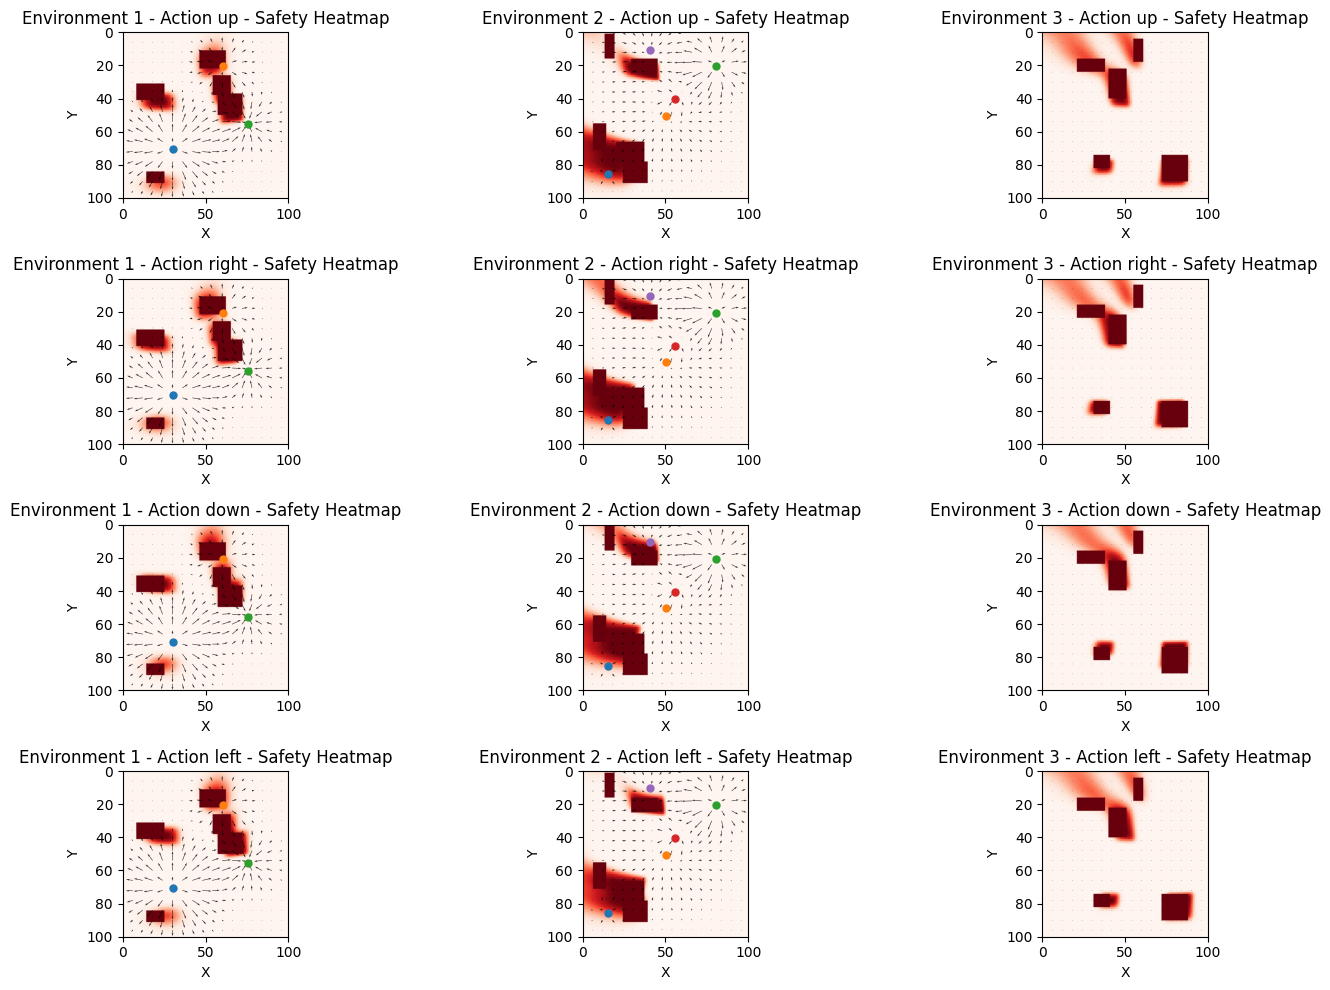

In [10]:
risk_maps = [[] for _ in range(len(envs))]

def plot_safety_heatmap(safety_map, env, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    im = ax.imshow(safety_map.T, origin='lower', extent=[0, 100, 0, 100], aspect='equal', cmap='Reds', vmin=0, vmax=1)
    
    env.plot_hills(ax=ax)

    return im

fig, axes = plt.subplots(4, len(envs), figsize=(15, 10))
for i, QRR in enumerate(qrvs):
    env = envs[i]
    S_q = state_sets[i].S_q
    for j, action in enumerate(actions.values()):
        un_safety_map = QRR[j].get_k_step_reachability(k=1)
        unsafe_map = np.ones((100, 100))
        unsafe_map[S_q[:, 0], S_q[:, 1]] = un_safety_map
        risk_maps[i].append(unsafe_map)
        im = plot_safety_heatmap(unsafe_map, env, ax=axes[j, i])
        axes[j, i].set_title(f'Environment {i+1} - Action {list(actions.keys())[j]} - Safety Heatmap')
    env.save_risk_maps(risk_maps[i])

plt.tight_layout()
plt.show()

In [11]:
EPISODES = 2000
MAX_STEPS = 200
ALPHA = 0.3
GAMMA = 0.9
EPSILON = 1
EPSILON_DECAY = 0.995
MIN_EPSILON = 0.05

def square_keep_sign(n):
    if n >= 0:
        return n ** 2
    else:
        return -(n ** 2)

def distance_to_goal(state, top=(x_top, y_top)):
    x, y = state
    return np.sqrt((x - top[0]) ** 2 + (y - top[1]) ** 2)

def get_risk_value(s, risk_map, S_q):
    return risk_map[s[0], s[1]]


def print_return(inp):
    print(inp)
    return inp

deltas = [0.1, 0.4, 0.7, 0.9]

mathcal_r = lambda s, s_prime, env: 100 if distance_to_goal(s_prime, env.reward_gaussian_mean) < 5 else square_keep_sign(distance_to_goal(s, env.reward_gaussian_mean) - distance_to_goal(s_prime, env.reward_gaussian_mean)) - 10


Training Episodes: 100%|██████████| 2000/2000 [00:05<00:00, 377.13it/s]
/var/folders/rv/b01cr15x4v1d0l_0f9t176nr0000gn/T/ipykernel_21588/3367640970.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  action_cmap = plt.cm.get_cmap('tab10', 4)
/var/folders/rv/b01cr15x4v1d0l_0f9t176nr0000gn/T/ipykernel_21588/3367640970.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', max(num_runs, 1))


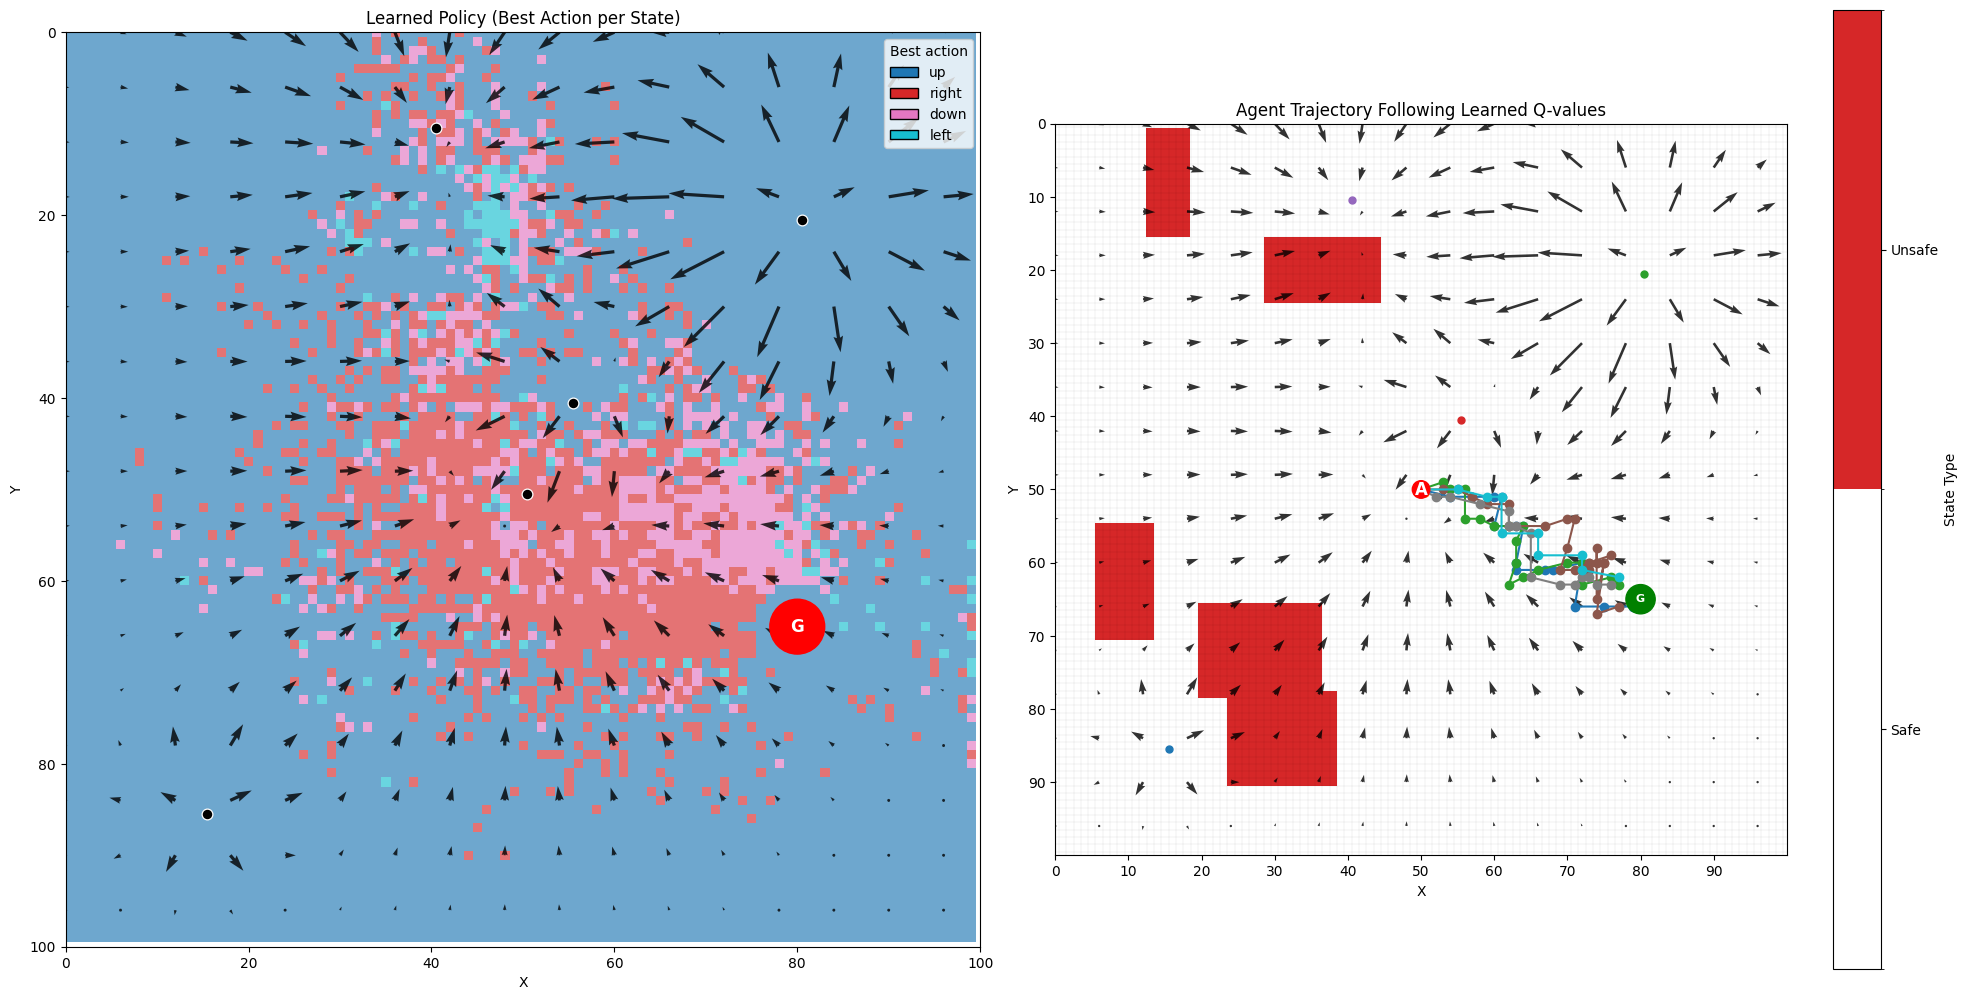

In [12]:
x_top, y_top = envs[1].reward_gaussian_mean

def plot_agent(location, ax=None, radius=1.2):
    x, y = location
    agent = Circle((x, y), radius=radius, color='red', zorder=3)
    ax.add_patch(agent)

    # Draw white 'A' in the center
    ax.text(
        x, y, 'A',
        color='white',
        fontsize=12,
        fontweight='bold',
        ha='center',    
        va='center',
        zorder=4
    )


actions = {
    'up': (0, -1),
    'right': (1, 0),
    'down': (0, 1),
    'left': (-1, 0),
}


def plot_policy(Q, env, ax=None):
    max_x, max_y = env.grid_shape
    policy_grid = np.argmax(Q, axis=2)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
    
    # Color each state by its best action
    # Use top-origin to match the rest of the environment visualizations (y=0 at top).
    action_cmap = plt.cm.get_cmap('tab10', 4)
    im = ax.imshow(
        policy_grid.T,
        cmap=action_cmap,
        origin='upper',
        interpolation='nearest',
        vmin=-0.5,
        vmax=3.5,
        alpha=0.65
    )
    
    # Keep hill vectors and hill-top markers on top.
    env.plot_hills(ax=ax, color='black')
    for top, *_ in env.hill_tops:
        tx, ty = top
        ax.scatter(tx + 0.5, ty + 0.5, s=60, c='black', edgecolors='white', linewidths=0.9, zorder=6)

    goal = Circle((x_top, y_top), radius=3, color='red', zorder=3)
    ax.add_patch(goal)

    # Draw white 'G' in the center
    ax.text(
        x_top, y_top, 'G',
        color='white',
        fontsize=12,
        fontweight='bold',
        ha='center',
        va='center',
        zorder=4
    ) 
    
    
    action_labels = ['up', 'right', 'down', 'left']
    legend_handles = [
        Patch(facecolor=action_cmap(i), edgecolor='black', label=label)
        for i, label in enumerate(action_labels)
    ]
    ax.legend(handles=legend_handles, title='Best action', loc='upper right', frameon=True)
    
    ax.set_title('Learned Policy (Best Action per State)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

def plot_run(Q, agent, env, start_state=(0, 0), max_steps=1000, num_runs=1, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    env.plot_unsafe_mask(ax=ax)
    env.plot_hills(ax=ax, color='black')

    plot_agent(start_state, ax=ax)
    

    goal = Circle((x_top, y_top), radius=2, color='green', zorder=3)
    ax.add_patch(goal)

    # Draw white 'G' in the center
    ax.text(
        x_top, y_top, 'G',
        color='white',
        fontsize=8,
        fontweight='bold',
        ha='center',
        va='center',
        zorder=4
    ) 

    colors = plt.cm.get_cmap('tab10', max(num_runs, 1))
    for run_idx in range(num_runs):
        s = start_state
        trajectory = [s]

        for _ in range(max_steps):
            x, y = s
            a_index = np.argmax(Q[x, y, :])
            a = list(actions.values())[a_index]
            s = env.transition(s, a)
            trajectory.append(s)

            if agent.distance_to_goal(s) < 5:
                break

        traj_x, traj_y = zip(*trajectory)
        ax.plot(
            traj_x, traj_y,
            marker='o',
            color=colors(run_idx),
            label=f'Run {run_idx + 1}' if num_runs > 1 else 'Agent Trajectory'
        )

    ax.set_title("Agent Trajectory Following Learned Q-values")

def plot_policies(Qs, env, agents, start_state=(0, 0), ax=None, titles=None):
    fig, ax = plt.subplots(len(Qs), 2,figsize=(20, len(Qs) * 10))

    for i, Q in enumerate(Qs):
        plot_policy(Q, env, ax=ax[i][0])
        plot_run(Q, agents[i], env, start_state, num_runs=5, ax=ax[i][1])
        if titles:
            ax[i][0].set_title(titles[i][0])
            ax[i][1].set_title(titles[i][1])

    fig.suptitle("Learned Policies and Trajectories for Different Risk Avoidance Strategies", fontsize=16)
    plt.show()

def plot_policy_and_run(Q, agent, env, start_state=(0, 0), max_steps=1000, ax=None):
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    plot_policy(Q, env, ax=ax[0])
    plot_run(Q, agent, env, start_state, max_steps=max_steps, num_runs=5, ax=ax[1])
    plt.tight_layout()
    plt.show()

from src.q_learning import QLearningAgent


model = models[1]  # Use the model for env2

env = envs[1]  # Use the second environment
S_q = state_sets[1].S_q
delta = 0.4  # Set delta to a specific value for this run
agent = QLearningAgent(
    env,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY,
    min_epsilon=MIN_EPSILON
)

_, _, unsafe_counts = agent.train(
    start_state,
    episodes=EPISODES,
    max_steps=MAX_STEPS,
    mathcal_R=mathcal_r,
    R=lambda s, a, delta, env: (
        get_risk_value(s, env.risk_maps[a], S_q),
        get_risk_value(s, env.risk_maps[a], S_q) < delta
    ),
    H=lambda rho: 50 * rho,
    C=lambda r, p: r - p,
    delta=delta,
)

plot_policy_and_run(agent.get_q_values(), agent, env, start_state=start_state, max_steps=MAX_STEPS)

In [14]:
from src.q_learning import QLearningAgent

start_state = (0, 0)
exp_one_unsafe_counts = [[] for _ in range(len(envs))]
exp_one_qs = [[] for _ in range(len(envs))]
exp_one_agents = [[] for _ in range(len(envs))]
for i, env in enumerate(envs):
    model = models[i]
    S_q = state_sets[i].S_q
    for delta in deltas:
        agent = QLearningAgent(
            env,
            alpha=ALPHA,
            gamma=GAMMA,
            epsilon=EPSILON,
            epsilon_decay=EPSILON_DECAY,
            min_epsilon=MIN_EPSILON
        )

        _, _, unsafe_counts = agent.train(
            start_state,
            episodes=EPISODES,
            max_steps=MAX_STEPS,
            mathcal_R=mathcal_r,
            R=lambda s, a, delta, env=env: (
                get_risk_value(s, env.risk_maps[a], S_q),
                get_risk_value(s, env.risk_maps[a], S_q) < delta
            ),
            H=lambda rho: 50 * rho,
            C=lambda r, p: r - p,
            delta=delta,
        )

        exp_one_unsafe_counts[i].append(unsafe_counts)
        exp_one_qs[i].append(agent.get_q_values())
        exp_one_agents[i].append(agent)

start_state = (0, 0)
exp_two_unsafe_counts = [[] for _ in range(len(envs))]
exp_two_qs = [[] for _ in range(len(envs))]
exp_two_agents = [[] for _ in range(len(envs))]
for i, env in enumerate(envs):
    model = models[i]
    S_q = state_sets[i].S_q
    for delta in deltas:
        agent = QLearningAgent(
            env,
            alpha=ALPHA,
            gamma=GAMMA,
            epsilon=EPSILON,
            epsilon_decay=EPSILON_DECAY,
            min_epsilon=MIN_EPSILON,
        )

        _, _, unsafe_counts = agent.train(
            start_state,
            episodes=EPISODES,
            max_steps=MAX_STEPS,
            mathcal_R=mathcal_r,
            R=lambda s, a, delta, env=env: (
                get_risk_value(s, env.risk_maps[a], S_q),
                get_risk_value(s, env.risk_maps[a], S_q) < delta
            ),
            H=lambda rho: (50 * rho) ** 2,
            C=lambda r, p: r - p,
            delta=delta
        )

        exp_two_unsafe_counts[i].append(unsafe_counts)
        exp_two_qs[i].append(agent.get_q_values())
        exp_two_agents[i].append(agent)

exp_three_unsafe_counts = [[] for _ in range(len(envs))]
exp_three_qs = [[] for _ in range(len(envs))]
exp_three_agents = [[] for _ in range(len(envs))]
for i, env in enumerate(envs):
    for delta in deltas:
        for zeta in [50, 100, 200]:
            agent = QLearningAgent(
                env,
                alpha=ALPHA,
                gamma=GAMMA,
                epsilon=EPSILON,
                epsilon_decay=EPSILON_DECAY,
                min_epsilon=MIN_EPSILON,
            )

            _, _, unsafe_counts = agent.train(
                start_state,
                episodes=EPISODES,
                max_steps=MAX_STEPS,
                mathcal_R=mathcal_r,
                R=lambda s, a, delta, env=env: (
                    get_risk_value(s, env.risk_maps[a], S_q),
                    get_risk_value(s, env.risk_maps[a], S_q) < delta
                ),
                H=lambda rho: rho,
                C=lambda r, p, delta=delta, zeta=zeta: (
                    -zeta if p > delta else r
                ),
                delta=delta,
            )

            exp_three_unsafe_counts[i].append(unsafe_counts)
            exp_three_qs[i].append(agent.get_q_values())
            exp_three_agents[i].append(agent)

Training Episodes: 100%|██████████| 2000/2000 [00:23<00:00, 84.48it/s] 


In [15]:
start_state = (0, 0)
exp_compare_unsafe_counts = [[] for _ in range(len(envs))]
exp_compare_qs = [[] for _ in range(len(envs))]
exp_compare_agents = [[] for _ in range(len(envs))]
for i, env in enumerate(envs):
    model = models[i]
    S_q = state_sets[i].S_q
    expiriments_compare = [
        (
            # mathcal_r (s, s', env -> r)
            mathcal_r,
            # R (s, a, env -> (rho, s_frak))
            lambda s, a, delta, env: (get_risk_value(s, env.risk_maps[a], S_q), True),
            # H (rho -> p)
            lambda rho: rho,
            # C (r, p -> r)
            lambda r, p: r
        ),
                (
            # mathcal_r (s, s', env -> r)
            mathcal_r,
            # R (s, a, env -> (rho, s_frak))
            lambda s, a, delta, env: (1 if list(s) not in S_q else 0, True),
            # H (rho -> p)
            lambda rho: rho * 100 
            ,
            # C (r, p -> r)
            lambda r, p: r - p
        ),
                (
            # mathcal_r (s, s', env -> r)
            mathcal_r,
            # R (s, a, env -> (rho, s_frak))
            lambda s, a, delta, env: (get_risk_value(s, env.risk_maps[a], S_q), True),
            # H (rho -> p)
            lambda rho: rho * 50,
            # C (r, p -> r)
            lambda r, p: r - p
        ),

        (
            # mathcal_r (s, s', env -> r)
            mathcal_r,
            # R (s, a, env -> (rho, s_frak))
            lambda s, a, delta, env: (0, get_risk_value(s, env.risk_maps[a], S_q)<0.4),
            # H (rho -> p)
            lambda rho: 0,
            # C (r, p -> r)
            lambda r, p: r
        )



    ]
    for exp in expiriments_compare:
        mathcal_r, R, H, C = exp
        agent = QLearningAgent(env, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON, epsilon_decay=EPSILON_DECAY, min_epsilon=MIN_EPSILON)
        _, _, unsafe_counts = agent.train(start_state, episodes=EPISODES, max_steps=MAX_STEPS,
                mathcal_R=mathcal_r, R=R, H=H, C=C)
        
        exp_compare_unsafe_counts[i].append(unsafe_counts)
        exp_compare_qs[i].append(agent.get_q_values())
        exp_compare_agents[i].append(agent)

Training Episodes: 100%|██████████| 2000/2000 [00:30<00:00, 64.72it/s]


In [16]:
import pickle

data = {
    "exp_one_unsafe_counts": exp_one_unsafe_counts,
    "exp_one_qs": exp_one_qs,
    "exp_one_agents": exp_one_agents,
    "exp_two_unsafe_counts": exp_two_unsafe_counts,
    "exp_two_qs": exp_two_qs,
    "exp_two_agents": exp_two_agents,
    "exp_three_unsafe_counts": exp_three_unsafe_counts,
    "exp_three_qs": exp_three_qs,
    "exp_three_agents": exp_three_agents,
    "exp_compare_unsafe_counts": exp_compare_unsafe_counts,
    "exp_compare_qs": exp_compare_qs,
    "exp_compare_agents": exp_compare_agents,
    "envs": envs,
    "models": models,
    "qrvs": qrvs,
    "state_sets": state_sets,

}

with open("data3.pkl", "wb") as f:
    pickle.dump(data, f)   

In [ ]:
def policy_accounted_action_estimates(Q, model, actions, env=env, action_rank=0):
    max_x, max_y = env.grid_shape

    pred_mean_with_policy = np.zeros((max_x, max_y, 2), dtype=np.float64)      # [x, y, mean_x, mean_y]
    pred_cov_with_policy  = np.zeros((max_x, max_y, 2, 2), dtype=np.float64)   # [x, y, cov(2x2)]

    action_list = list(actions.values())

    for x in range(max_x):
        for y in range(max_y):
            # allow for selecting the 2nd best action (action_rank=1) or 3rd best (action_rank=2)
            sorted_indices = np.argsort(Q[x, y, :])[::-1]
            selected_action_index = sorted_indices[action_rank]
            selected_action = action_list[selected_action_index]

            x_input = torch.tensor([[x, y, selected_action[0], selected_action[1]]], dtype=torch.float64)
            pred_mean, pred_cov = model.predict(x_input)

            mean_np = pred_mean.squeeze(0).detach().cpu().numpy()   # shape (2,)
            cov_np  = pred_cov.detach().cpu().numpy()               # shape (2,2)

            pred_mean_with_policy[x, y] = mean_np
            pred_cov_with_policy[x, y] = cov_np

    return pred_mean_with_policy, pred_cov_with_policy

#save the post training qrvs for the post training shielding
post_training_qrvs_exp_one = [[] for _ in range(len(envs))]
for i, Q_per_delta in enumerate(exp_one_qs):
    model = models[i]
    S_q = state_sets[i].S_q
    q = state_sets[i].q
    S = state_sets[i].S
    env = envs[i]
    for Q in Q_per_delta:
        pred_mean_with_policy, pred_cov_with_policy = policy_accounted_action_estimates(Q, model, actions, env=env)
        A, b_ = calc_quantative_reachability_values(S, S_q, q, pred_mean_with_policy, pred_cov_with_policy, env=env)
        post_training_qrvs_exp_one[i].append(QuantitativeReachabilityResult(A, b_))
        print("its cooked")


post_training_qrvs_exp_two = [[] for _ in range(len(envs))]
for i, Q_per_delta in enumerate(exp_two_qs):
    model = models[i]
    S_q = state_sets[i].S_q
    q = state_sets[i].q
    S = state_sets[i].S
    env = envs[i]
    for Q in Q_per_delta:
        pred_mean_with_policy, pred_cov_with_policy = policy_accounted_action_estimates(Q, model, actions, env=env)
        A, b_ = calc_quantative_reachability_values(S, S_q, q, pred_mean_with_policy, pred_cov_with_policy, env=env)
        post_training_qrvs_exp_two[i].append(QuantitativeReachabilityResult(A, b_))

post_training_qrvs_exp_three = [[] for _ in range(len(envs))]
for i, Q_per_delta in enumerate(exp_three_qs):
    model = models[i]
    S_q = state_sets[i].S_q
    q = state_sets[i].q
    S = state_sets[i].S
    env = envs[i]
    for Q in Q_per_delta:
        pred_mean_with_policy, pred_cov_with_policy = policy_accounted_action_estimates(Q, model, actions, env=env)
        A, b_ = calc_quantative_reachability_values(S, S_q, q, pred_mean_with_policy, pred_cov_with_policy, env=env)
        post_training_qrvs_exp_three[i].append(QuantitativeReachabilityResult(A, b_))

post_training_qrvs_exp_compare = [[] for _ in range(len(envs))]
for i, Q_per_delta in enumerate(exp_compare_qs):
    model = models[i]
    S_q = state_sets[i].S_q
    q = state_sets[i].q
    S = state_sets[i].S
    env = envs[i]
    for Q in Q_per_delta:
        pred_mean_with_policy, pred_cov_with_policy = policy_accounted_action_estimates(Q, model, actions, env=env)
        A, b_ = calc_quantative_reachability_values(S, S_q, q, pred_mean_with_policy, pred_cov_with_policy, env=env)
        post_training_qrvs_exp_compare[i].append(QuantitativeReachabilityResult(A, b_))


KeyboardInterrupt: 

In [ ]:
import pickle

data = {
    "post_training_qrvs_exp_one": post_training_qrvs_exp_one,
    "post_training_qrvs_exp_two": post_training_qrvs_exp_two,
    "post_training_qrvs_exp_three": post_training_qrvs_exp_three,
    "post_training_qrvs_exp_compare": post_training_qrvs_exp_compare,
}

with open("data4.pkl", "wb") as f:
    pickle.dump(data, f)        

In [ ]:
def distance_to_goal(state, top=(x_top, y_top)):
    x, y = state
    return np.sqrt((x - top[0]) ** 2 + (y - top[1]) ** 2)

def get_risk_value(s, risk_map, S_q):
    return risk_map[s[0], s[1]]

def simulate_runs(Q, env, R, start_state=(0, 0), max_steps=1000, num_runs=1, actions=actions):
    for run_idx in range(num_runs):
        s = start_state
        for _ in range(max_steps):
            x, y = s
            a_index = np.argmax(Q[x, y, :])
            a = list(actions.values())[a_index]
            rank = 0
            lowest_risk = 1
            risk, safe = R(s, a)
            while not safe:
                if risk < lowest_risk:
                    lowest_risk = risk
                    least_risky_action = a
                rank += 1
                a_index = np.argsort(Q[x, y, :])[rank]
                a = list(actions.values())[a_index]
                risk, safe = R(s)
                if rank == len(actions) and not safe:
                    a = least_risky_action
                    safe = True

            s = env.transition(s, a)
            if env.unsafe_mask[s]:
                unsafe_count += 1
                break

            if distance_to_goal(s, top=(x_top, y_top)) < 5:
                finished_count += 1
                break

    return unsafe_count, finished_count

In [ ]:
exp_one_post_training_shield_one_step = []
for i, Q_per_delta in enumerate(exp_one_qs[:]):
    env = envs[i]
    S_q = state_sets[i].S_q
    one_step_map = post_training_qrvs_exp_one[i].get_k_step_reachability(1).reshape(env.grid_shape)
    unsafe_map = np.ones((100, 100))
    unsafe_map[S_q[:, 0], S_q[:, 1]] = one_step_map
    for j, Q in enumerate(Q_per_delta):
        unsafe_count, finished_count = simulate_runs(Q, env, lambda s: (get_risk_value(s, unsafe_map[s[0]][s[1]], S_q), get_risk_value(s, unsafe_map[s[0]][s[1]], S_q)<0.4), num_runs=100)
        exp_one_post_training_shield_one_step.append((unsafe_count, finished_count))

exp_two_post_training_shield_one_step = []
for i, Q_per_delta in enumerate(exp_two_qs[:]):
    env = envs[i]
    S_q = state_sets[i].S_q
    one_step_map = post_training_qrvs_exp_two[i].get_k_step_reachability(1).reshape(env.grid_shape)
    unsafe_map = np.ones((100, 100))
    unsafe_map[S_q[:, 0], S_q[:, 1]] = one_step_map
    for j, Q in enumerate(Q_per_delta):
        unsafe_count, finished_count = simulate_runs(Q, env, lambda s: (get_risk_value(s, unsafe_map[s[0]][s[1]], S_q), get_risk_value(s, unsafe_map[s[0]][s[1]], S_q)<0.4), num_runs=100)
        exp_two_post_training_shield_one_step.append((unsafe_count, finished_count))

exp_three_post_training_shield_one_step = []
for i, Q_per_delta in enumerate(exp_three_qs[:]):
    env = envs[i]
    S_q = state_sets[i].S_q
    one_step_map = post_training_qrvs_exp_three[i].get_k_step_reachability(1).reshape(env.grid_shape)
    unsafe_map = np.ones((100, 100))
    unsafe_map[S_q[:, 0], S_q[:, 1]] = one_step_map
    for j, Q in enumerate(Q_per_delta):
        unsafe_count, finished_count = simulate_runs(Q, env, lambda s: (get_risk_value(s, unsafe_map[s[0]][s[1]], S_q), get_risk_value(s, unsafe_map[s[0]][s[1]], S_q)<0.4), num_runs=100)
        exp_three_post_training_shield_one_step.append((unsafe_count, finished_count))

exp_compare_post_training_shield_one_step = []
for i, Q_per_delta in enumerate(exp_compare_qs[:]):
    env = envs[i]
    S_q = state_sets[i].S_q
    one_step_map = post_training_qrvs_exp_compare[i].get_k_step_reachability(1).reshape(env.grid_shape)
    unsafe_map = np.ones((100, 100))
    unsafe_map[S_q[:, 0], S_q[:, 1]] = one_step_map
    for j, Q in enumerate(Q_per_delta):
        unsafe_count, finished_count = simulate_runs(Q, env, lambda s: (get_risk_value(s, unsafe_map[s[0]][s[1]], S_q), get_risk_value(s, unsafe_map[s[0]][s[1]], S_q)<0.4), num_runs=100)
        exp_compare_post_training_shield_one_step.append((unsafe_count, finished_count))

exp_one_post_training_shield_two_step = []
for i, Q_per_delta in enumerate(exp_one_qs[:]):
    env = envs[i]
    S_q = state_sets[i].S_q
    two_step_map = post_training_qrvs_exp_one[i].get_k_step_reachability(2).reshape(env.grid_shape)
    unsafe_map = np.ones((100, 100))
    unsafe_map[S_q[:, 0], S_q[:, 1]] = two_step_map
    for j, Q in enumerate(Q_per_delta):
        unsafe_count, finished_count = simulate_runs(Q, env, lambda s: (get_risk_value(s, unsafe_map[s[0]][s[1]], S_q), get_risk_value(s, unsafe_map[s[0]][s[1]], S_q)<0.4), num_runs=100)
        exp_one_post_training_shield_two_step.append((unsafe_count, finished_count))

exp_two_post_training_shield_two_step = []
for i, Q_per_delta in enumerate(exp_two_qs[:]):
    env = envs[i]
    S_q = state_sets[i].S_q
    two_step_map = post_training_qrvs_exp_two[i].get_k_step_reachability(2).reshape(env.grid_shape)
    unsafe_map = np.ones((100, 100))
    unsafe_map[S_q[:, 0], S_q[:, 1]] = two_step_map
    for j, Q in enumerate(Q_per_delta):
        unsafe_count, finished_count = simulate_runs(Q, env, lambda s: (get_risk_value(s, unsafe_map[s[0]][s[1]], S_q), get_risk_value(s, unsafe_map[s[0]][s[1]], S_q)<0.4), num_runs=100)
        exp_two_post_training_shield_two_step.append((unsafe_count, finished_count))

exp_three_post_training_shield_two_step = []
for i, Q_per_delta in enumerate(exp_three_qs[:]):
    env = envs[i]
    S_q = state_sets[i].S_q
    two_step_map = post_training_qrvs_exp_three[i].get_k_step_reachability(2).reshape(env.grid_shape)
    unsafe_map = np.ones((100, 100))
    unsafe_map[S_q[:, 0], S_q[:, 1]] = two_step_map
    for j, Q in enumerate(Q_per_delta):
        unsafe_count, finished_count = simulate_runs(Q, env, lambda s: (get_risk_value(s, unsafe_map[s[0]][s[1]], S_q), get_risk_value(s, unsafe_map[s[0]][s[1]], S_q)<0.4), num_runs=100)
        exp_three_post_training_shield_two_step.append((unsafe_count, finished_count))

exp_compare_post_training_shield_two_step = []
for i, Q_per_delta in enumerate(exp_compare_qs[:]):
    env = envs[i]
    S_q = state_sets[i].S_q
    two_step_map = post_training_qrvs_exp_compare[i].get_k_step_reachability(2).reshape(env.grid_shape)
    unsafe_map = np.ones((100, 100))
    unsafe_map[S_q[:, 0], S_q[:, 1]] = two_step_map
    for j, Q in enumerate(Q_per_delta):
        unsafe_count, finished_count = simulate_runs(Q, env, lambda s: (get_risk_value(s, unsafe_map[s[0]][s[1]], S_q), get_risk_value(s, unsafe_map[s[0]][s[1]], S_q)<0.4), num_runs=100)
        exp_compare_post_training_shield_two_step.append((unsafe_count, finished_count))

In [ ]:
def extract_metric(data, idx):
    return np.array([x[idx] for x in data])

zetas = [50, 100, 200]


for metric_idx, ylabel in [(0, "Unsafe count"), (1, "Finished count")]:

    exp1 = np.stack([
        extract_metric(exp_one_post_training_shield_one_step, metric_idx).reshape(3, len(deltas)),
        extract_metric(exp_one_post_training_shield_two_step, metric_idx).reshape(3, len(deltas))
    ], axis=-1)

    exp2 = np.stack([
        extract_metric(exp_two_post_training_shield_one_step, metric_idx).reshape(3, len(deltas)),
        extract_metric(exp_two_post_training_shield_two_step, metric_idx).reshape(3, len(deltas))
    ], axis=-1)

    exp3 = np.stack([
        extract_metric(exp_three_post_training_shield_one_step, metric_idx).reshape(3, len(deltas), len(zetas)),
        extract_metric(exp_three_post_training_shield_two_step, metric_idx).reshape(3, len(deltas), len(zetas))
    ], axis=-1)

    compare = np.stack([
        extract_metric(exp_compare_post_training_shield_one_step, metric_idx).reshape(3, 3),
        extract_metric(exp_compare_post_training_shield_two_step, metric_idx).reshape(3, 3)
    ], axis=-1)

    fig, ax = plt.subplots(figsize=(20, 7))

    colors = ['C0', 'C1', 'C2']
    env_names = ['Env 1', 'Env 2', 'Env 3']

    bar_width = 0.04
    exp_gap = 0.15
    group_gap = 0.8

    # width of one delta group
    group_width = (
        3 * 2 * bar_width +          # Exp1
        exp_gap +
        3 * 2 * bar_width +          # Exp2
        exp_gap +
        3 * len(zetas) * 2 * bar_width  # Exp3
    )

    # +1 for compare group
    x_centers = np.arange(len(deltas) + 1) * (group_width + group_gap)


    for d_idx, x0 in enumerate(x_centers[:-1]):

        offset = 0

        for env in range(3):
            for shield in range(2):

                ax.bar(
                    x0 + offset,
                    exp1[env, d_idx, shield],
                    width=bar_width,
                    color=colors[env],
                    hatch='' if shield == 0 else '//'
                )

                offset += bar_width

        offset += exp_gap

        for env in range(3):
            for shield in range(2):

                ax.bar(
                    x0 + offset,
                    exp2[env, d_idx, shield],
                    width=bar_width,
                    color=colors[env],
                    hatch='' if shield == 0 else '//'
                )

                offset += bar_width

        offset += exp_gap

        for env in range(3):
            for zeta_idx in range(len(zetas)):
                for shield in range(2):

                    ax.bar(
                        x0 + offset,
                        exp3[env, d_idx, zeta_idx, shield],
                        width=bar_width,
                        color=colors[env],
                        alpha=0.5 + 0.15 * zeta_idx,
                        hatch='' if shield == 0 else '//'
                    )

                    offset += bar_width


    x0 = x_centers[-1]
    offset = 0

    compare_gap = 0.15

    for compare_idx in range(3):

        for env in range(3):
            for shield in range(2):

                ax.bar(
                    x0 + offset,
                    compare[env, compare_idx, shield],
                    width=bar_width,
                    color=colors[env],
                    hatch='' if shield == 0 else '//'
                )

                offset += bar_width

        offset += compare_gap

    compare_width = offset

    xtick_positions = list(x_centers[:-1] + group_width / 2)
    xtick_positions.append(x_centers[-1] + compare_width / 2)

    xtick_labels = [f"δ={δ}" for δ in deltas]
    xtick_labels.append("Compare")

    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels)

    ax.set_xlabel("δ")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Post-training {ylabel}")

    env_handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors[i])
        for i in range(3)
    ]

    shield_handles = [
        plt.Rectangle((0, 0), 1, 1, color='lightgray'),
        plt.Rectangle((0, 0), 1, 1, color='lightgray', hatch='//')
    ]

    zeta_handles = [
        plt.Rectangle((0, 0), 1, 1, color='gray',
                      alpha=0.5 + 0.15*i)
        for i in range(len(zetas))
    ]

    legend1 = ax.legend(
        env_handles,
        env_names,
        title="Environment",
        loc='upper left'
    )

    ax.add_artist(legend1)

    legend2 = ax.legend(
        shield_handles,
        ["1-step shield", "2-step shield"],
        title="Shield depth",
        loc='upper right'
    )

    ax.add_artist(legend2)

    legend3 = ax.legend(
        zeta_handles,
        [f"ζ={z}" for z in zetas],
        title="Zeta (Exp3)",
        loc='center right'
    )

    ax.add_artist(legend3)

    plt.tight_layout()
    plt.show()